In [8]:
%pip install opencv-python scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


# American Sign Language (ASL) Recognition using PCA
## Project Overview
This project aims to build a robust **Hand Gesture Recognition** system using **Principal Component Analysis (PCA)** for dimensionality reduction and feature extraction. The system is designed to classify 29 categories of ASL (A-Z + Space, Delete, Nothing).

### Objectives:
1. **Data Preprocessing:** Standardizing image sizes, noise reduction, and grayscale conversion.
2. **Augmentation:** Enhancing the dataset to handle lighting and rotation variances.
3. **Dimensionality Reduction:** Utilizing PCA to capture the most significant "EigenHands".
4. **Real-time Integration:** Preparing the pipeline for Live Inference via Webcam.

### Dataset Insights:
- **Total Images:** 87,000.
- **Resolution:** 200x200 Pixels.
- **Classes:** 29 (26 Letters + 3 Special Tokens).
- **Environment:** Kaggle Notebook environment.

In [9]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


In [10]:
import sys
print(sys.executable)

c:\Users\Nour\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [11]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'tensorflow'

## Load data and samples

In [ ]:
base_path = "/kaggle/input/datasets/grassknoted/asl-alphabet"

print(os.listdir(base_path))

['asl_alphabet_test', 'asl_alphabet_train']


In [ ]:
TRAIN_DIR = '/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train'
IMG_SIZE = (64, 64) # Optimal for PCA efficiency
CLASSES = sorted(os.listdir(TRAIN_DIR))

print(f"Total Classes: {len(CLASSES)}")

Total Classes: 29


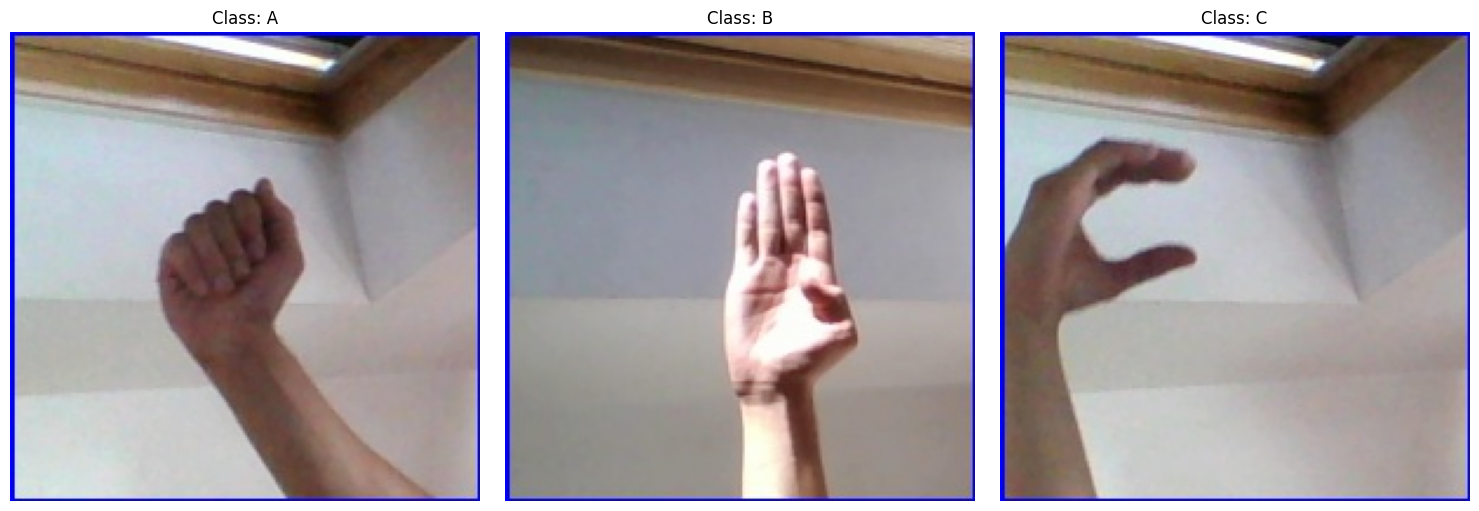

In [ ]:
def load_sample_images(data_dir, classes, num_samples=3):
    plt.figure(figsize=(15, 5))
    for i, cls in enumerate(classes[:3]): # Displaying first 3 classes as sample
        img_path = glob(os.path.join(data_dir, cls, "*.jpg"))[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"Class: {cls}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

load_sample_images(TRAIN_DIR, CLASSES)

## Data preprocessing

In [ ]:
def professional_preprocess_pipeline(image, target_size=IMG_SIZE):
    
    # 1. Resize
    img_resized = cv2.resize(image, target_size)
    
    # 2. Skin Segmentation (YCrCb Space)
    img_ycrcb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_ycrcb, lower_skin, upper_skin)
    
    # 3. Clean Mask (Morphology)
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    
    # 4. Feature Extraction (Canny Edges)
    # Applying edges on the masked image removes background clutter
    masked_img = cv2.bitwise_and(img_resized, img_resized, mask=mask)
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    
    # 5. Normalization
    normalized_edges = edges / 255.0
    
    return normalized_edges, mask

print("Preprocessing Pipeline Defined.")

Preprocessing Pipeline Defined.


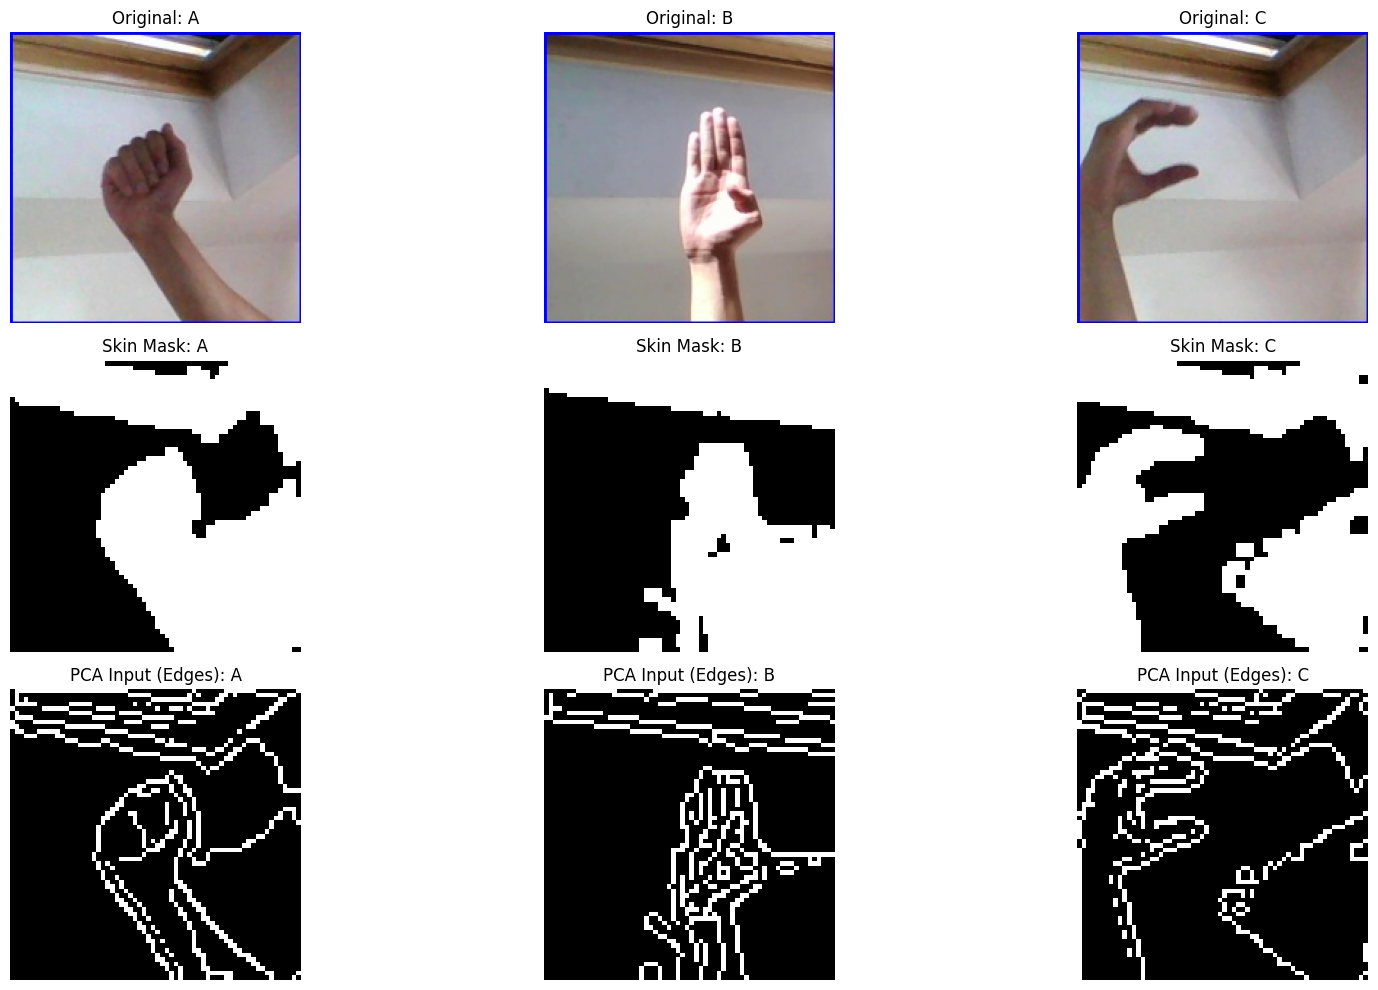

In [ ]:
# show_pipeline_steps

def show_pipeline_steps(num_classes=3):
    plt.figure(figsize=(18, 10))
    
    for i in range(num_classes):
        cls = CLASSES[i]
        path = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))[0]
        original = cv2.imread(path)
        processed, mask = professional_preprocess_pipeline(original)
        
        # Original
        plt.subplot(3, num_classes, i + 1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {cls}")
        plt.axis('off')
        
        # Mask
        plt.subplot(3, num_classes, i + 1 + num_classes)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Skin Mask: {cls}")
        plt.axis('off')
        
        # Final Edge Input
        plt.subplot(3, num_classes, i + 1 + 2*num_classes)
        plt.imshow(processed, cmap='gray')
        plt.title(f"PCA Input (Edges): {cls}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_pipeline_steps()

In [ ]:
# Augmentation

augmenter = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    fill_mode='constant',
    cval=0
)

print("Augmentation Strategy initialized.")

Augmentation Strategy initialized.


In [ ]:
# Mass Processing & Structural Augmentation

# Initialize data containers
X = []
y = []

# Set samples per class: 400 original + 400 augmented = 800 total samples per class
SAMPLES_PER_CLASS = 400 

print(f"Processing {SAMPLES_PER_CLASS} base images + Augmentation per class...")

for label, cls in enumerate(CLASSES):
    # Fetch image paths for the current class
    img_paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))[:SAMPLES_PER_CLASS]
    
    for path in img_paths:
        # 1. Execute Professional Pipeline (Skin Masking & Edge Detection)
        raw_img = cv2.imread(path)
        processed_img, _ = professional_preprocess_pipeline(raw_img)
        
        # 2. Append original processed image (Flattened for PCA)
        X.append(processed_img.flatten())
        y.append(label)
        
        # 3. Apply Augmentation
        # Reshape to (H, W, 1) to comply with the ImageDataGenerator requirements
        img_reshaped = processed_img.reshape(IMG_SIZE[0], IMG_SIZE[1], 1)
        
        # Generate a single random transformation (rotation, zoom, brightness)
        augmented_img = augmenter.random_transform(img_reshaped)
        
        # Append augmented version (Flattened)
        X.append(augmented_img.flatten())
        y.append(label)

# Convert to Numpy arrays with float32
X = np.array(X, dtype='float32')
y = np.array(y)

print(f" Preprocessing & Augmentation Complete!")
print(f" Final Dataset Shape: {X.shape}") 
print(f" Total Unique Labels: {len(np.unique(y))}")

Processing 400 base images + Augmentation per class...
 Preprocessing & Augmentation Complete!
 Final Dataset Shape: (23200, 4096)
 Total Unique Labels: 29


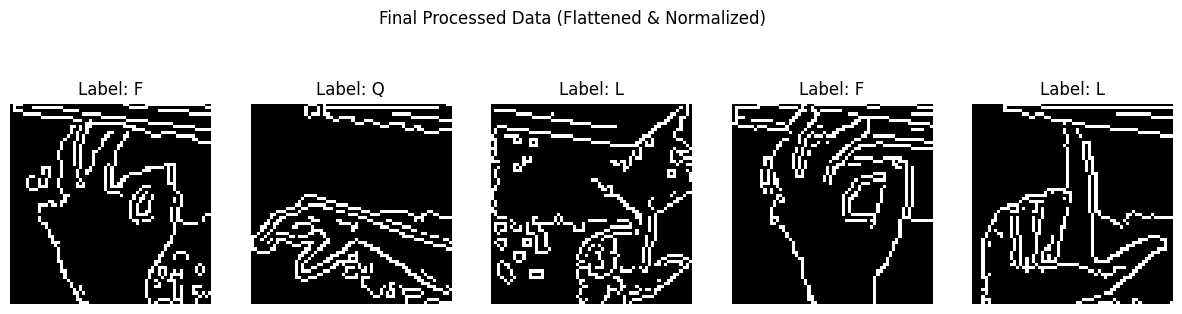

In [ ]:
# Final Data Audit (Visualizing Processed Samples)

plt.figure(figsize=(15, 4))
indices = np.random.choice(len(X), 5)

for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[idx].reshape(IMG_SIZE), cmap='gray')
    plt.title(f"Label: {CLASSES[y[idx]]}")
    plt.axis('off')

plt.suptitle("Final Processed Data (Flattened & Normalized)")
plt.show()

In [ ]:
# Live Inference Pipeline & Temporal Smoothing logic

import time
from collections import Counter

def prepare_live_frame(frame, target_size=IMG_SIZE):
    """
    Standardizes incoming webcam frames to match the PCA training format.
    """
    # Use the same professional pipeline we used for training
    processed_frame, _ = professional_preprocess_pipeline(frame, target_size)
    
    # Return flattened for PCA prediction
    return processed_frame.flatten().reshape(1, -1)

class TemporalSmoother:
    """
    Prevents prediction flickering by using a rolling buffer (Voting Mechanism).
    """
    def __init__(self, buffer_size=5):
        self.buffer = []
        self.buffer_size = buffer_size

    def smooth_predict(self, new_prediction):
        self.buffer.append(new_prediction)
        if len(self.buffer) > self.buffer_size:
            self.buffer.pop(0)
        
        # Return the most frequent prediction in the buffer
        most_common = Counter(self.buffer).most_common(1)
        return most_common[0][0]

# Initialize the smoother for later use in the Live script
smoother = TemporalSmoother(buffer_size=7)

print("Live Inference Pipeline & Temporal Smoother are ready.")

Live Inference Pipeline & Temporal Smoother are ready.


## Applying PCA: The "Compression" Step

In [ ]:
# 1) Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 2) PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.show()

In [ ]:
# HOG Feature Extraction (Optional - for reference)
# from skimage.feature import hog
# Select a sample image from X and reshape it
# sample_img = X[0].reshape(IMG_SIZE)
# features, hog_image = hog(
#     sample_img,
#     orientations=9,
#     pixels_per_cell=(8,8),
#     cells_per_block=(2,2),
#     visualize=True,

#     block_norm='L2-Hys'
# )

KeyboardInterrupt: 

In [ ]:
print(features.shape)

In [ ]:
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")
plt.axis('off')
plt.show()

## Train/Test Split

In [ ]:
# 3) Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train ML Models

### SVM Model

In [ ]:
# 4) SVM Model
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

### KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)

## Accuracy Comparison Graph

In [ ]:
models = ['SVM', 'KNN']
accuracies = [svm_acc, knn_acc]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap='Blues')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

## KNN Accuracy vs K Graph

In [ ]:
k_values = range(1, 11)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,5))

plt.plot(k_values, scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")

plt.show()